# Read the NDB annotation mmCIF *through* rnaglib

rnaglib can't open `data/00008bwt.mmcif` directly — its only file path runs **FR3D**, which
needs `_atom_site` coordinates that this annotation-only file doesn't have (it errors with
`Unknown block atom_site`).

But the file already contains what an rnaglib 2.5D graph stores — base pairs + Leontis–Westhof
families. So we use a tiny adapter (`ndb_to_rnaglib.py`) to rewrite it into rnaglib's native
graph format, then read it back with **rnaglib's own `load_graph`**:

```
data/00008bwt.mmcif  ──ndb_mmcif_to_rnaglib_graph──▶  rnaglib node-link JSON  ──load_graph──▶  graph
```

Graph follows rnaglib conventions: nodes `8bwt.A.<seq>` with `nt_code`; edges carry an `LW`
label — base pairs (`cWW`, `tWS`, …, reverse direction transposed to `tSW`) plus backbone
(`B53`/`B35`).

In [2]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt

from ndb_to_rnaglib import ndb_mmcif_to_rnaglib_graph   # the adapter
from rnaglib.utils import dump_json, load_graph          # rnaglib's own I/O
from rnaglib.drawing import rna_draw                     # rnaglib's 2.5D drawing

MMCIF = Path("../../../data/00008bwt.mmcif").resolve()
print(MMCIF, MMCIF.exists())

/Users/cw_liao/na-hackathon-2026/workstreams/ws1-annotation-validation/mmcif-to-pyg/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


No LaTex installation was found, using a fallback drawing system.
/Users/cw_liao/na-hackathon-2026/data/00008bwt.mmcif True


## 1. Convert and let rnaglib read it (model 1)

In [3]:
# adapter: new-scheme mmCIF -> rnaglib graph -> JSON
G1 = ndb_mmcif_to_rnaglib_graph(MMCIF, model=1)
dump_json("8bwt_model1.rnaglib.json", G1)

# rnaglib reads the file we just wrote
R1 = load_graph("8bwt_model1.rnaglib.json")
print("read by rnaglib:", type(R1).__name__, "| pdbid:", R1.graph["pdbid"])
print("nodes:", R1.number_of_nodes(), "| edges:", R1.number_of_edges())

n0 = list(R1.nodes)[0]
print("sample node:", n0, "->", {k: R1.nodes[n0][k] for k in ("nt_code", "chain_id", "is_modified")})
print("LW edge labels:", dict(Counter(d["LW"] for *_, d in R1.edges(data=True))))

read by rnaglib: DiGraph | pdbid: 8bwt
nodes: 26 | edges: 72
sample node: 8bwt.A.1 -> {'nt_code': 'G', 'chain_id': 'A', 'is_modified': False}
LW edge labels: {'cWW': 22, 'B53': 25, 'B35': 25}


## 2. Draw it with rnaglib's 2.5D drawing

`rna_draw` lays nucleotides on a circle, backbone as black arrows, base pairs with
Leontis–Westhof glyphs (⊕ = cis Watson–Crick). Model 1 is all cWW.

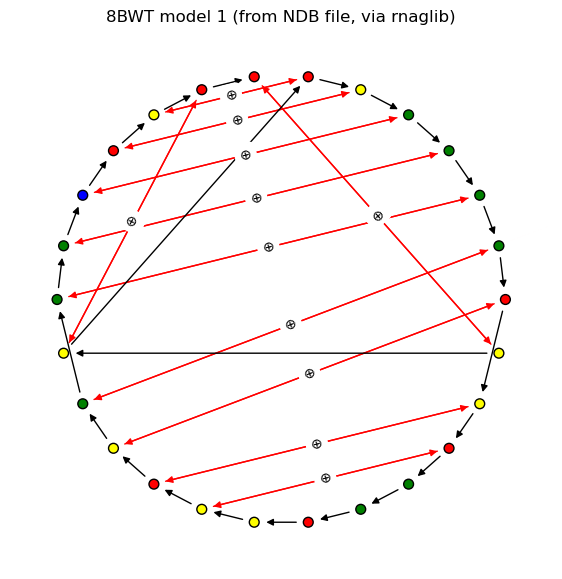

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
rna_draw(R1, title="8BWT model 1 (from NDB file, via rnaglib)", ax=ax, node_ids=True, show=False)
plt.show()

## 3. Non-canonical pairs (model 3)

The adapter passes through **any** LW family. Model 3 contains a non-canonical **tWS** pair
(G15·U12); rnaglib's directed-edge convention stores the reverse as **tSW**.

In [6]:
G3 = ndb_mmcif_to_rnaglib_graph(MMCIF, model=3)
dump_json("8bwt_model3.rnaglib.json", G3)
R3 = load_graph("8bwt_model3.rnaglib.json")

print("LW edge labels:", dict(Counter(d["LW"] for *_, d in R3.edges(data=True))))
noncanonical = [(u, v, d["LW"]) for u, v, d in R3.edges(data=True)
                if d["LW"] not in ("cWW", "B53", "B35")]
print("\nnon-canonical edges:")
for u, v, lw in noncanonical:
    print(f"  {u} -> {v}   LW={lw}")

LW edge labels: {'cWW': 22, 'B53': 25, 'B35': 25, 'tWS': 1, 'tSW': 1}

non-canonical edges:
  8bwt.A.15 -> 8bwt.A.12   LW=tWS
  8bwt.A.12 -> 8bwt.A.15   LW=tSW


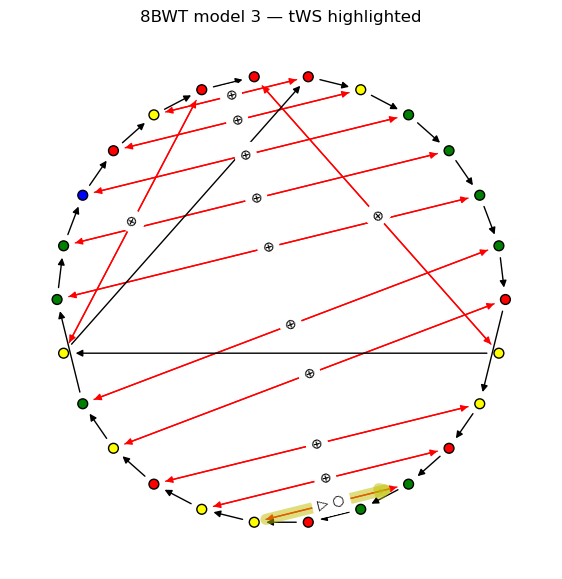

In [7]:
# highlight the non-canonical pair in the drawing
highlight = [(u, v) for u, v, lw in noncanonical if lw == "tWS"]
fig, ax = plt.subplots(figsize=(7, 7))
rna_draw(R3, title="8BWT model 3 — tWS highlighted", ax=ax, node_ids=True,
         highlight_edges=highlight, show=False)
plt.show()